<a href="https://colab.research.google.com/github/Naimur125/Linear/blob/main/220106_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Salary_dataset.csv to Salary_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Salary_dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [ ]:
print(df.shape)
print(df.columns)
df.info()

(30, 3)
Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [ ]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

[115791.21011287  71499.27809463 102597.86866063  75268.80422384
  55478.79204548  60190.69970699]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 6286.453830757742
MSE: 49830096.85590836
R2 Score: 0.9024461774180498


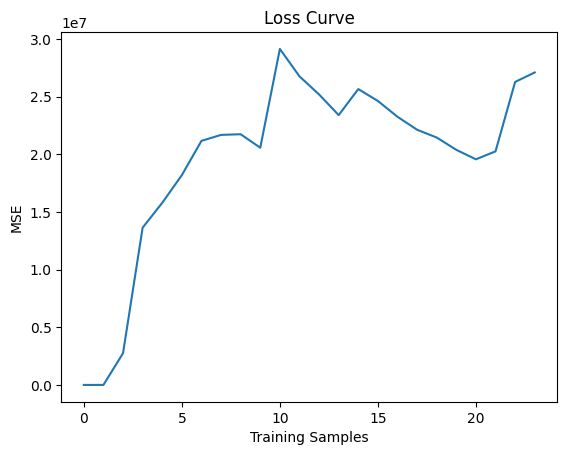

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

losses = []

for i in range(1, len(X_train)+1):
    temp_model = LinearRegression()
    temp_model.fit(X_train[:i], y_train[:i])
    pred = temp_model.predict(X_train[:i])
    losses.append(mean_squared_error(y_train[:i], pred))

plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Training Samples")
plt.ylabel("MSE")
plt.show()

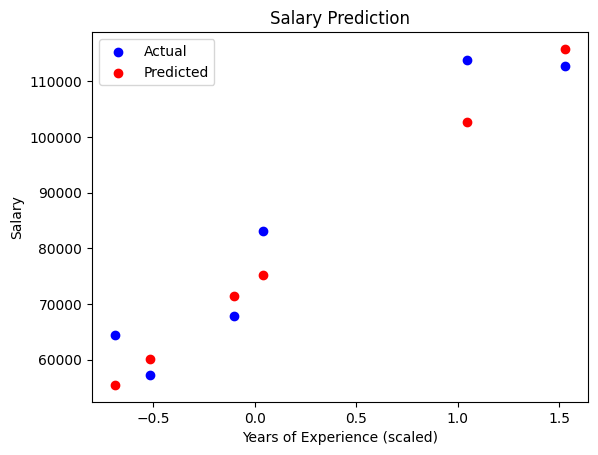

In [ ]:
plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.scatter(X_test, y_pred, color="red", label="Predicted")

plt.title("Salary Prediction")
plt.xlabel("Years of Experience (scaled)")
plt.ylabel("Salary")
plt.legend()
plt.show()